# Experiment 5: Parameter Sensitivity Analysis

**Drug Modeled:** Gefitinib

**Condition Tested:** Sensitivity of the spatial proliferation response P(x) to
selected model parameters.

**Research Question:** Which model parameters most strongly control the predicted spatial
proliferation response to heterogeneous gefitinib exposure?

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters

# Spatial domain
L = 0.2
nx = 200
x = np.linspace(0, L, nx)
dx = x[1] - x[0]

# Solver tolerances
rtol = 1e-9
atol = 1e-12

# Validated diffusion model
D1 = 5e-7
D2 = 1e-7
D3 = 5e-7

boundary_1 = 0.05
boundary_2 = 0.12

C_source = 1.0

T_diffusion = 3600
nt = 30000
dt = T_diffusion / nt

# Load validated exp04b outputs
G = np.load("saved_parameters/exp04b_G.npy")
T_steady = np.load("saved_parameters/exp04b_T_steady.npy")

# Initial state vector
y0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

# Parameter dictionary
params_baseline = {
    "EGF" : 1.0,
    "IC_50" : 0.3,
    "n" : 1.0,
    "k_EGF" : 1.0,
    "k_EGFR_off" : 0.5,
    "k_G" : 0.5,
    "k_RAS" : 1.0,
    "k_RAS_off" : 0.5,
    "k_RAF" : 1.0,
    "k_RAF_off" : 0.5,
    "k_MEK" : 1.0,
    "k_MEK_off" : 0.5,
    "k_ERK" : 1.0,
    "k_ERK_off" : 0.5,
    "k_T" : 1.0,
    "k_deg" : 0.5,
    "k_P" : 1.0,
    "k_loss" : 0.5,
}

In [36]:
# ODE Signaling Function
def pathway(t, y, params, G_x):
    # External factors
    EGF = params["EGF"]
    G = G_x
    IC_50 = params["IC_50"]
    n = params["n"]

    # Extract activated protein and Cyclin D/Proliferation rates from array y
    EGFR_star, RAS_star, RAF_star, MEK_star, ERK_star, CycD, P = y

    # Total protein concentrations
    EGFR_tot = 1.0
    RAS_tot = 1.0
    RAF_tot = 1.0
    MEK_tot = 1.0
    ERK_tot = 1.0

    # Rate constants (normalized currently)
    k_EGF = params["k_EGF"]
    k_EGFR_off = params["k_EGFR_off"]
    k_G = params["k_G"]

    k_RAS = params["k_RAS"]
    k_RAS_off = params["k_RAS_off"]

    k_RAF = params["k_RAF"]
    k_RAF_off = params["k_RAF_off"]

    k_MEK = params["k_MEK"]
    k_MEK_off = params["k_MEK_off"]

    k_ERK = params["k_ERK"]
    k_ERK_off = params["k_ERK_off"]

    k_T = params["k_T"]
    k_deg = params["k_deg"]

    k_P = params["k_P"]
    k_loss = params["k_loss"]

    # Calculating derivatives
    EGFR_gefit = 1 / (1 + (G / IC_50) ** n)
    EGFR_act = k_EGF * EGF * (EGFR_tot - EGFR_star) * EGFR_gefit
    EGFR_dect = k_EGFR_off * EGFR_star

    dEGFR = EGFR_act - EGFR_dect

    RAS_act = k_RAS * EGFR_star * (RAS_tot - RAS_star)
    RAS_dect = k_RAS_off * RAS_star

    dRAS = RAS_act - RAS_dect

    RAF_act = k_RAF * RAS_star * (RAF_tot - RAF_star)
    RAF_dect = k_RAF_off * RAF_star

    dRAF = RAF_act - RAF_dect

    MEK_act = k_MEK * RAF_star * (MEK_tot - MEK_star)
    MEK_dect = k_MEK_off * MEK_star

    dMEK = MEK_act - MEK_dect

    ERK_act = k_ERK * MEK_star * (ERK_tot - ERK_star)
    ERK_dect = k_ERK_off * ERK_star

    dERK = ERK_act - ERK_dect

    CycD_act = k_T * ERK_star
    CycD_dect = k_deg * CycD

    dCycD = CycD_act - CycD_dect

    P_act = k_P * CycD
    P_dect = k_loss * P

    dP = P_act - P_dect

    return [dEGFR, dRAS, dRAF, 
                dMEK, dERK, dCycD, dP]

In [37]:
# Building baseline solutions array
solutions_baseline = np.zeros((7, nx))

for i in range(nx):
    G_local = G[i]

    sol = solve_ivp(
        pathway,
        [0, T_steady],
        y0,
        args=(params_baseline, G_local),
        rtol=rtol,
        atol=atol
    )

    solutions_baseline[:, i] = sol.y[:, -1]

## Baseline Validation

Before performing sensitivity analysis, confirm that the baseline
reproduces the validated exp04b behavior.

In [38]:
# Test 1 : Monotonicity
print("Conducting Test 1 : Monotonicity...")

names = [
    "EGFR*", "RAS*", "RAF*", "MEK*",
    "ERK*", "CycD", "P"
]

for j, name in enumerate(names):

    diff = np.diff(solutions_baseline[j])

    print(
        name,
        "reversals:",
        np.sum(diff < 0)
    )

# Test 2 : Steady-state Residual
print("Conducting Test 2 : Steady-state Residual...")

max_rates = np.zeros(nx)

for i in range(nx):

    dydt = pathway(
        T_steady,
        solutions_baseline[:, i],
        params_baseline,
        G[i]
    )

    max_rates[i] = np.max(np.abs(dydt))

print(
    "Maximum absolute final derivative:",
    np.max(max_rates)
)

Conducting Test 1 : Monotonicity...
EGFR* reversals: 0
RAS* reversals: 0
RAF* reversals: 0
MEK* reversals: 0
ERK* reversals: 0
CycD reversals: 0
P reversals: 0
Conducting Test 2 : Steady-state Residual...
Maximum absolute final derivative: 2.8789474137980164e-09


## Sensitivity Metric

To quantify how strongly each model parameter controls the predicted
spatial heterogeneity in proliferation, spatial proliferation
heterogeneity is quantified using the coefficient of variation:

$$
CV_P = \frac{\sigma_P}{\mu_P}
$$

where $\sigma_P$ is the standard deviation and $\mu_P$ is the mean of
the steady-state proliferation values $P(x)$ across the tissue.

The coefficient of variation measures the magnitude of spatial
variation relative to the mean proliferation level. Unlike a
maximum–minimum range, it incorporates the proliferation response
across the entire spatial domain.

For each parameter $p$, the model is evaluated at perturbed values
while all other parameters are held at their validated baseline
values. The resulting spatial proliferation heterogeneity is
quantified as $CV_P(p)$.

The response is normalized to the validated exp04b baseline:

$$
CV_{P,\mathrm{norm}}(p) = \frac{CV_P(p)}{CV_{P,0}}
$$

where $CV_{P,0}$ is the coefficient of variation obtained from the
validated baseline model.

Thus,

$$
CV_{P,\mathrm{norm}}(p_0)=1
$$

at the baseline parameter value $p_0$.

To quantify parameter sensitivity, a normalized finite-difference
sensitivity coefficient is calculated from the lower and upper
perturbations:

$$
S_p =
\frac{
\left(CV_{P,+}-CV_{P,-}\right)/CV_{P,0}
}{
(p_+-p_-)/p_0
}
$$

where $CV_{P,-}$ and $CV_{P,+}$ are the spatial proliferation
heterogeneity responses at the lower and upper parameter values,
respectively.

This approximates the logarithmic sensitivity:

$$
S_p \approx
\frac{\partial \ln CV_P}{\partial \ln p}
$$

The magnitude $|S_p|$ is used to rank parameters by their influence
on predicted spatial proliferation heterogeneity.

- $|S_p| > 1$: the relative response changes more than the relative parameter
  change.
- $|S_p| \approx 1$: the relative response changes approximately
  proportionally to the parameter.
- $|S_p| < 1$: the relative response changes less than proportionally
  to the parameter.

The sign of $S_p$ indicates the direction of the relationship:
$S_p > 0$ indicates that increasing the parameter increases spatial
proliferation heterogeneity, while $S_p < 0$ indicates that increasing
the parameter decreases spatial proliferation heterogeneity.

Each parameter is analyzed independently using the same validated
exp04b baseline model, with all non-perturbed parameters held at their
baseline values.

## Sensitivity Parameters

Three model components will be tested: effective drug transport,
drug potency, and the steepness of the drug-response relationship.

### Diffusion Multiplier

The validated exp04b model contains three layer-specific diffusion
coefficients:

$$
D_1 = 5 * 10^{-7},

D_2 = 1 * 10^{-7},

D_3 = 5 * 10^{-7}
$$

Rather than varying these coefficients independently, a dimensionless
diffusion multiplier $(\alpha_D)$ will be used:

$$
D_{i'} = \alpha_D D_i
$$

for $(i=1,2,3)$.

The baseline value is therefore

$$
\alpha_D = 1
$$

which reproduces the validated exp04b diffusion model.

This approach changes the overall effective rate of gefitinib
transport while preserving the validated relative differences in
diffusivity between tissue layers.

The diffusion multiplier will therefore be varied independently of
$(IC_{50})$ and $(n)$.

In [39]:
# Provisional sensitivity ranges
# These ranges are exploratory and will be updated
# when literature-supported parameter ranges are established.

sensitivity_parameters = {
    "D_multiplier": np.sort(
        np.append(
            np.logspace(np.log10(0.2), np.log10(2.0), 10),
            1.0
        )
    ),
    "IC_50": np.linspace(0.15, 0.60, 10),
    "n": np.linspace(0.5, 2.0, 10)
}

In [40]:
# Diffusion profile generation
# Used for sensitivity analysis of diffusion coefficient (D_multiplier)

def generate_G(D_multiplier):
    # Scale validated diffusion coefficients
    D1_current = D1 * D_multiplier
    D2_current = D2 * D_multiplier
    D3_current = D3 * D_multiplier

    # Build spatial diffusitivity profile
    D_current = np.full(nx, D1_current)
    D_current[x >= boundary_1] = D2_current
    D_current[x >= boundary_2] = D3_current

    # Initial concentration
    C = np.zeros(nx)
    C[0] = C_source

    # Diffusion simulation
    for t in range(nt):
        C_new = C.copy()

        for i in range(1, nx - 1):
            D_left = (D_current[i] + D_current[i - 1]) / 2
            D_right = (D_current[i] + D_current[i + 1]) / 2

            J_left = -D_left * (C[i] - C[i - 1]) / dx
            J_right = -D_right * (C[i + 1] - C[i]) / dx

            C_new[i] = C[i] + (dt / dx) * (J_left - J_right)

        C = C_new

        # Constant source boundary
        C[0] = C_source

    return C

In [41]:
# Central ODE simulation function

def run_spatial_model(params, G_profile):
    solutions = np.zeros((7, len(x)))

    for i in range(len(x)):
        G_local = G_profile[i]

        sol = solve_ivp(
            pathway,
            [0, T_steady],
            y0,
            args=(params, G_local),
            rtol=rtol,
            atol=atol
        )

        solutions[:, i] = sol.y[:, -1]

    return solutions

In [ ]:
# # Validated baseline spatial proliferation response

solutions_test = run_spatial_model(params_baseline, G)
P_baseline = solutions_test[6]

CV_P_baseline = np.std(P_baseline) / np.mean(P_baseline)

np.save(
    "saved_parameters/exp05_CV_P_baseline.npy",
    CV_P_baseline
)


## I. IC50 Parameter Sweep

This section shall examine the effect of the $IC_{50}$ parameter on the spatial proliferation response $P(x)$. 

**Definition:** The concentration of an inhibitor required to reduce a specified biological/biochemical activity by 50% under defined experimental conditions. In this model, the inhibitior is gefitinib, and the biological activity is EGFR activation.

In [43]:
# Solving IC50 responses
IC50_values = sensitivity_parameters["IC_50"]
IC50_responses = []

for value in IC50_values:

    # Update parameter dictionary
    params = params_baseline.copy()
    params["IC_50"] = value

    # Run signaling/proliferation model
    solutions = run_spatial_model(
        params,
        G
    )

    # Extract proliferation
    P_1 = solutions[6]

    # Calculate spatial proliferation heterogeneity
    CV_P1 = np.std(P_1) / np.mean(P_1)

    IC50_responses.append(CV_P1)

IC50_responses = np.array(IC50_responses)

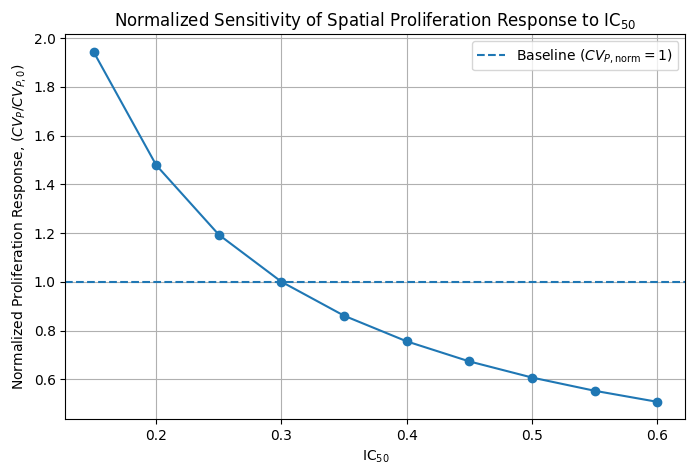

In [ ]:
# Plot normalized responses (normalized to CV_P_baseline)
IC50_responses_norm = IC50_responses / CV_P_baseline

plt.figure(figsize=(8, 5))

plt.plot(IC50_values, IC50_responses_norm, marker="o")

plt.axhline(1.0, linestyle="--", label=r"Baseline ($CV_{P,\mathrm{norm}} = 1$)")

plt.xlabel(r"$\mathrm{IC}_{50}$")
plt.ylabel(r"Normalized Proliferation Response, (${CV}_P/{CV}_{P,0}$)")
plt.title(r"Normalized Sensitivity of Spatial Proliferation Response to $\mathrm{IC}_{50}$")
plt.grid(True)

plt.legend()
plt.savefig("figures/exp05_IC50_sweep")
plt.show()

## II. Hill Coefficient Parameter Sweep

This section shall examine the effect of the Hill coefficient ($n$) parameter on the spatial proliferation response $P(x)$. 

**Definition:** Characterizes the steepness of the dose–response relationship, with larger values producing a more switch-like response and smaller values producing a more gradual response.

In [45]:
# Solving Hill responses
hill_values = sensitivity_parameters["n"]
hill_responses = []

for value in hill_values:

    # Update dictionary values
    params = params_baseline.copy()
    params["n"] = value

    # Run signaling/proliferation model
    solutions = run_spatial_model(
        params,
        G
    )

    # Extract proliferation
    P_2 = solutions[6]

    # Calculate spatial proliferation response
    CV_P2 = np.std(P_2) / np.mean(P_2)

    hill_responses.append(CV_P2)

hill_responses = np.array(hill_responses)

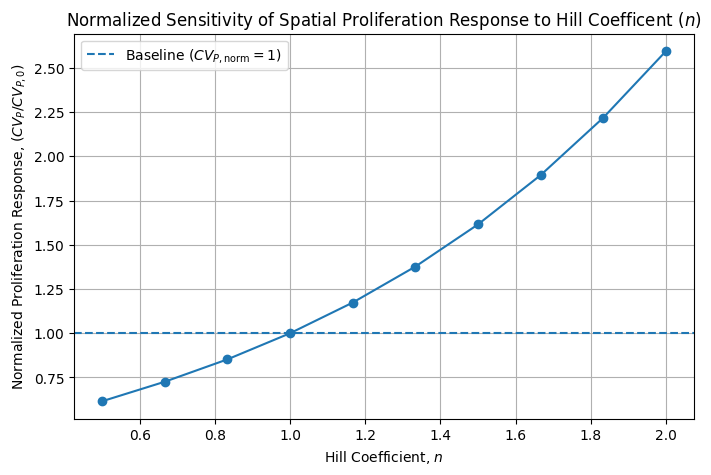

In [ ]:
# Plot normalized responses (normalized to CV_P_baseline)
hill_responses_norm = hill_responses / CV_P_baseline

plt.figure(figsize=(8, 5))

plt.plot(hill_values, hill_responses_norm, marker="o")

plt.axhline(1.0, linestyle="--", label=r"Baseline ($CV_{P,\mathrm{norm}} = 1$)")

plt.xlabel(r"Hill Coefficient, $n$")
plt.ylabel(r"Normalized Proliferation Response, (${CV}_P/{CV}_{P,0}$)")
plt.title(r"Normalized Sensitivity of Spatial Proliferation Response to Hill Coefficent ($n$)")
plt.grid(True)

plt.legend()
plt.savefig("figures/exp05_hill_sweep")
plt.show()

## III. Diffusion Coefficent Parameter Sweep

This section shall examine the effect of the diffusion coefficient ($D$) parameter on the spatial proliferation response $P(x)$. 

**Definition:** Quantifies the rate at which a substance diffuses through a medium in response to a concentration gradient. Larger diffusion coefficients correspond to faster spatial transport.

In [47]:
# Solving diffusion coefficient responses
D_multiplier_values = sensitivity_parameters["D_multiplier"]
D_responses = []

for D_multiplier in D_multiplier_values:

    # Generate new spatial gefitinib profile
    G_current = generate_G(D_multiplier=D_multiplier)

    # Run signaling/proliferation model
    solutions = run_spatial_model(
        params_baseline,
        G_current
    )

    # Extract proliferation
    P_3 = solutions[6]

    # Calculate spatial proliferation response
    CV_P3 = np.std(P_3) / np.mean(P_3)

    D_responses.append(CV_P3)

D_responses = np.array(D_responses)


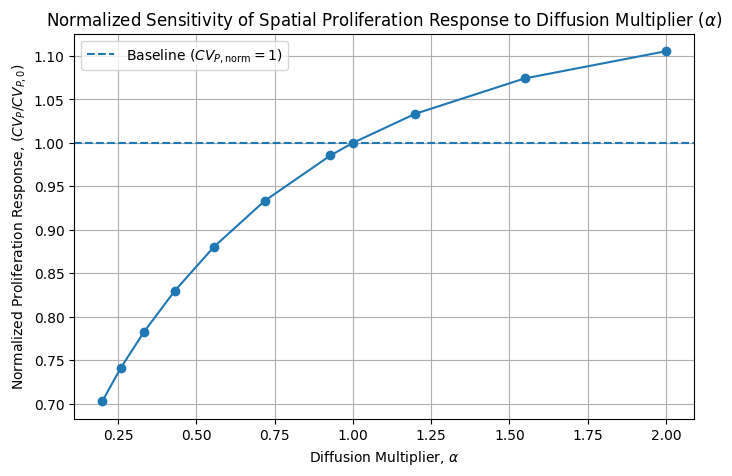

In [ ]:
# Plot normalized responses (normalized to CV_P_baseline)
D_responses_norm = D_responses / CV_P_baseline

plt.figure(figsize=(8, 5))

plt.plot(D_multiplier_values, D_responses_norm, marker="o")

plt.axhline(1.0, linestyle="--", label=r"Baseline ($CV_{P,\mathrm{norm}} = 1$)")

plt.xlabel(r"Diffusion Multiplier, $\alpha$")
plt.ylabel(r"Normalized Proliferation Response, (${CV}_P/{CV}_{P,0}$)")
plt.title(r"Normalized Sensitivity of Spatial Proliferation Response to Diffusion Multiplier ($\alpha$)")
plt.grid(True)

plt.legend()
plt.savefig("figures/exp05_hill_sweep")
plt.show()

## Local Sensitivity Calculation

The parameter-response sweeps above characterize how spatial
proliferation heterogeneity changes across a broad range of parameter
values. To quantify the sensitivity of the model specifically around
the validated baseline, a local finite-difference sensitivity
coefficient is calculated for each parameter.

For a baseline parameter value $p_0$, the parameter is perturbed
symmetrically in logarithmic space by $\pm 10\%$:

$$
p_- = \frac{p_0}{1.10}
\qquad\text{and}\qquad
p_+ = 1.10p_0
$$

This multiplicative perturbation is used because the sensitivity
metric is defined in terms of relative changes:

$$
S_p \approx
\frac{\partial \ln CV_P}{\partial \ln p}.
$$

Using a relative rather than absolute perturbation allows parameters
with different numerical scales and units to be compared on the same
basis.

The sensitivity coefficient is estimated using the central finite
difference:

$$
S_p =
\frac{
(CV_{P,+}-CV_{P,-})/CV_{P,0}
}{
(p_+-p_-)/p_0
}
$$

where $CV_{P,0}$ is the validated baseline spatial proliferation
heterogeneity, and $CV_{P,-}$ and $CV_{P,+}$ are the responses to the
lower and upper parameter perturbations.

A $\pm10\%$ perturbation provides a balance between approximating the
local derivative and avoiding sensitivity to small numerical changes.
The same relative perturbation is applied independently to each
parameter so that their sensitivity coefficients can be compared
directly.

The magnitude $|S_p|$ will be used to rank parameters according to
their influence on predicted spatial proliferation heterogeneity,
while the sign indicates whether increasing the parameter increases
or decreases $CV_P$ near the baseline.

In [65]:
# Parameter & Response perturbations

# Baselines
IC50_0 = params_baseline["IC_50"]
hill_0 = params_baseline["n"]
alpha_D_0 = 1.0
CV_P_0 = np.load("saved_parameters/exp05_CV_P_baseline.npy")

# Negative perturbations
IC50_minus = IC50_0 / 1.10
hill_minus = hill_0 / 1.10
alpha_D_minus = alpha_D_0 / 1.10

# Positive perturbations
IC50_plus = IC50_0 * 1.10
hill_plus = hill_0 * 1.10
alpha_D_plus = alpha_D_0 * 1.10

# Sensitivity Coefficient function
def calculate_sensitivity(CV_minus, CV_plus, p_minus, p_plus, p_0):
    relative_response_change = (
        CV_plus - CV_minus
    ) / CV_P_0

    relative_parameter_change = (
        p_plus - p_minus
    ) / p_0

    return relative_response_change / relative_parameter_change

In [66]:
# 1. IC50 Sensitivity Coefficent

# Negative perturbation response
params_minus = params_baseline.copy()
params_minus["IC_50"] = IC50_minus

solutions_minus = run_spatial_model(
    params_minus,
    G
)

P_minus = solutions_minus[6]

CV_P_IC50_minus = np.std(P_minus) / np.mean(P_minus)

# Positive perturbation response
params_plus = params_baseline.copy()
params_plus["IC_50"] = IC50_plus

solutions_plus = run_spatial_model(
    params_plus,
    G
)

P_plus = solutions_plus[6]

CV_P_IC50_plus = np.std(P_plus) / np.mean(P_plus)

# Sensitivity coefficient
S_IC50 = calculate_sensitivity(
    CV_minus=CV_P_IC50_minus,
    CV_plus=CV_P_IC50_plus,
    p_minus=IC50_minus,
    p_plus=IC50_plus,
    p_0=IC50_0
)

np.save("saved_parameters/exp05_S_IC50.npy", S_IC50)

In [67]:
# 2. Hill Sensitivity Coefficent

# Negative perturbation response
params_minus = params_baseline.copy()
params_minus["n"] = hill_minus

solutions_minus = run_spatial_model(
    params_minus,
    G
)

P_minus = solutions_minus[6]

CV_P_n_minus = np.std(P_minus) / np.mean(P_minus)

# Positive perturbation response
params_plus = params_baseline.copy()
params_plus["n"] = hill_plus

solutions_plus = run_spatial_model(
    params_plus,
    G
)

P_plus = solutions_plus[6]

CV_P_n_plus = np.std(P_plus) / np.mean(P_plus)

# Sensitivity coefficient
S_n = calculate_sensitivity(
    CV_minus=CV_P_n_minus,
    CV_plus=CV_P_n_plus,
    p_minus=hill_minus,
    p_plus=hill_plus,
    p_0=hill_0
)

np.save("saved_parameters/exp05_S_n.npy", S_n)

In [80]:
# 3. Diffusion Multiplier Sensitivity Coefficent

# Negative perturbation response
G_minus = generate_G(alpha_D_minus)

solutions_minus = run_spatial_model(
    params_baseline,
    G_minus
)

P_minus = solutions_minus[6]

CV_P_alpha_minus = np.std(P_minus) / np.mean(P_minus)

# Positive perturbation response
G_plus = generate_G(alpha_D_plus)

solutions_plus = run_spatial_model(
    params_baseline,
    G_plus
)

P_plus = solutions_plus[6]

CV_P_alpha_plus = np.std(P_plus) / np.mean(P_plus)

# Sensitivity coefficient
S_alpha = calculate_sensitivity(
    CV_minus=CV_P_alpha_minus,
    CV_plus=CV_P_alpha_plus,
    p_minus=alpha_D_minus,
    p_plus=alpha_D_plus,
    p_0=alpha_D_0
)

np.save("saved_parameters/exp05_S_alpha.npy", S_alpha)

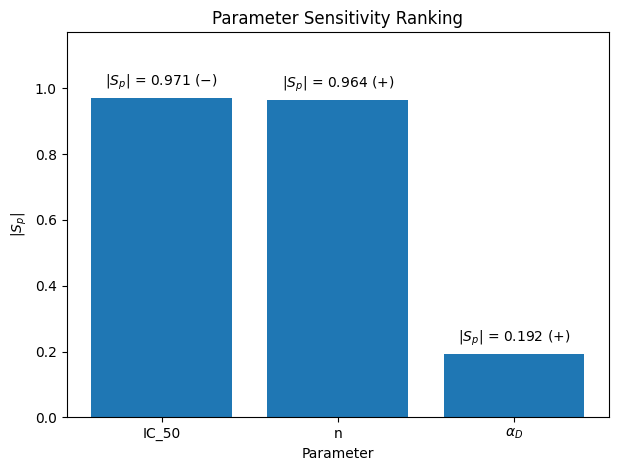

In [85]:
parameters = ["IC_50", "n", r"$\alpha_D$"]
S_values = [
    np.load("saved_parameters/exp05_S_IC50.npy"),
    np.load("saved_parameters/exp05_S_n.npy"),
    np.load("saved_parameters/exp05_S_alpha.npy")
]

magnitudes = np.abs(S_values)

plt.figure(figsize=(7, 5))
bars = plt.bar(parameters, magnitudes)

plt.xlabel("Parameter")
plt.ylabel(r"$|S_p|$")
plt.title("Parameter Sensitivity Ranking")

for bar, S in zip(bars, S_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"$|S_p|$ = {abs(S):.3f} ({'+' if S > 0 else '−'})",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(magnitudes) + 0.2)
plt.show()

## Sensitivity Analysis Results

The local sensitivity coefficients calculated using a $\pm10\%$
log-symmetric perturbation are summarized below. Parameters are ranked
by the magnitude of their sensitivity coefficient, $|S_p|$, which
represents the strength of their influence on predicted spatial
proliferation heterogeneity.

The sign of $S_p$ indicates the direction of the relationship between
the parameter and $CV_P$. A positive value indicates that increasing
the parameter increases spatial proliferation heterogeneity, whereas
a negative value indicates that increasing the parameter decreases
spatial proliferation heterogeneity.

![Sensitivity analysis results](figures/sensitivity_results.png)

The results indicate that $IC_{50}$ and $n$ have substantially greater
local sensitivity than $D_{\mathrm{eff}}$ within the validated model.
The magnitudes of the $IC_{50}$ and $n$ sensitivities are approximately
equal, while the sensitivity to $D_{\mathrm{eff}}$ is considerably
smaller.